<a href="https://colab.research.google.com/github/DayanapOrtilla/CV-DayanaPortilla/blob/master/fuzzy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Control Inteligente de Semáforos con Lógica Difusa


Descripción breve del objetivo: sistema de lógica difusa que ajusta automáticamente
los tiempos de semáforos según las tasas de congestión vehicular de las calles
que convergen en un crucero.

**Parte 1: Setup + Variables de Entrada y Salida**

El notebook está dividido en 3 partes:
- Parte 1 (aquí): instalación, imports, universo de discurso, variables de entrada y salida
- Parte 2: las 61 reglas difusas organizadas en 4 grupos
- Parte 3: sistema de control, simulaciones y análisis de resultados

In [ ]:
!pip install -U scikit-fuzzy

# PASO 1: Importaciones

Usamos `numpy` para manejar arreglos numéricos y definir el universo de discurso.
`skfuzzy` aporta las funciones de membresía trapezoidales. `skfuzzy.control`
permite crear variables lingüísticas y el sistema de control. `matplotlib.pyplot`
se usa para visualizar las funciones de membresía.

In [ ]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

# PASO 2: Universo de Discurso

El universo de discurso es el rango de valores posibles que toma cada variable
difusa. Aquí se normaliza en `[0.0, 1.0]` con paso `0.01` para representar la tasa
de congestión de forma estándar. `0` significa ausencia de congestión y `1`
significa congestión máxima. En el paper, las tasas originales van de `0` a `75`
vehículos y luego se normalizan a `[0, 1]`.

In [ ]:
# Universo de discurso normalizado [0.0, 1.0]
# Representa la tasa de congestión vehicular: 0 = libre, 1 = completamente congestionado
universo = np.arange(0, 1.01, 0.01)

# PASO 3: Variables de Entrada (Antecedent)

Un `Antecedent` en `scikit-fuzzy` representa una variable de entrada lingüística.
Aquí, `s1`, `s2`, `s3` y `s4` modelan las cuatro calles que convergen en el crucero.
Cada variable usa los mismos 5 conjuntos difusos trapezoidales del paper.

| Etiqueta | Nombre | Puntos trapezoidales (a, b, c, d) |
|---|---|---|
| `vl` | Muy bajo (very low) | (0.0, 0.0, 0.1866, 0.2133) |
| `lo` | Bajo (low) | (0.1866, 0.2133, 0.3866, 0.4133) |
| `me` | Medio (medium) | (0.3866, 0.4133, 0.5866, 0.6133) |
| `hi` | Alto (high) | (0.5866, 0.6133, 0.7866, 0.8133) |
| `vh` | Muy alto (very high) | (0.7866, 0.8133, 1.0, 1.0) |

Las 4 variables de entrada comparten exactamente esta misma partición.

In [ ]:
# Crear las 4 variables de entrada (Antecedent)
# Cada una representa la tasa de congestión de una calle del crucero
s1 = ctrl.Antecedent(universo, 's1')
s2 = ctrl.Antecedent(universo, 's2')
s3 = ctrl.Antecedent(universo, 's3')
s4 = ctrl.Antecedent(universo, 's4')

# Asignamos la misma estructura del paper para mantener consistencia en todas las calles
def definir_membresias(variable):
    variable['vl'] = fuzz.trapmf(variable.universe, [0.0,    0.0,    0.1866, 0.2133])
    variable['lo'] = fuzz.trapmf(variable.universe, [0.1866, 0.2133, 0.3866, 0.4133])
    variable['me'] = fuzz.trapmf(variable.universe, [0.3866, 0.4133, 0.5866, 0.6133])
    variable['hi'] = fuzz.trapmf(variable.universe, [0.5866, 0.6133, 0.7866, 0.8133])
    variable['vh'] = fuzz.trapmf(variable.universe, [0.7866, 0.8133, 1.0,    1.0   ])

# Aplicar a las 4 entradas
definir_membresias(s1)
definir_membresias(s2)
definir_membresias(s3)
definir_membresias(s4)

print('Variables de entrada creadas: s1, s2, s3, s4')
print('Conjuntos difusos por variable: vl, lo, me, hi, vh')

Variables de entrada creadas: s1, s2, s3, s4
Conjuntos difusos por variable: vl, lo, me, hi, vh


# PASO 4: Variables de Salida (Consequent)

Un `Consequent` en `scikit-fuzzy` representa una variable de salida. Aquí se crean
15 variables que corresponden al tiempo recomendado de luz verde para cada combinación
posible de calles congestionadas. Son 15 porque se agrupan como 4 de 1 calle, 6 de 2
calles, 4 de 3 calles y 1 de 4 calles. Todas usan defusificación por `centroid`,
como en el paper.

| Grupo | Variables |
|---|---|
| 1 calle | tCS1, tCS2, tCS3, tCS4 |
| 2 calles | tCS12, tCS13, tCS14, tCS23, tCS24, tCS34 |
| 3 calles | tCS123, tCS124, tCS134, tCS234 |
| 4 calles | tCS1234 |

In [ ]:
# Nombres de las 15 variables de salida
nombres_salida = [
    'tCS1', 'tCS2', 'tCS3', 'tCS4',           # 1 calle congestionada
    'tCS12', 'tCS13', 'tCS14',                # 2 calles (parte 1)
    'tCS23', 'tCS24', 'tCS34',                # 2 calles (parte 2)
    'tCS123', 'tCS124', 'tCS134', 'tCS234',   # 3 calles
    'tCS1234'                                 # 4 calles
]

# Creamos cada salida con el método centroid para mantener la defusificación del artículo
salidas = {}
for nombre in nombres_salida:
    salidas[nombre] = ctrl.Consequent(universo, nombre, defuzzify_method='centroid')
    definir_membresias(salidas[nombre])

# Desempaquetamos las variables para que queden listas para la Parte 2
tCS1    = salidas['tCS1']
tCS2    = salidas['tCS2']
tCS3    = salidas['tCS3']
tCS4    = salidas['tCS4']
tCS12   = salidas['tCS12']
tCS13   = salidas['tCS13']
tCS14   = salidas['tCS14']
tCS23   = salidas['tCS23']
tCS24   = salidas['tCS24']
tCS34   = salidas['tCS34']
tCS123  = salidas['tCS123']
tCS124  = salidas['tCS124']
tCS134  = salidas['tCS134']
tCS234  = salidas['tCS234']
tCS1234 = salidas['tCS1234']

print(f'Variables de salida creadas: {len(nombres_salida)}')
for nombre in nombres_salida:
    print(f'  {nombre}')

Variables de salida creadas: 15
  tCS1
  tCS2
  tCS3
  tCS4
  tCS12
  tCS13
  tCS14
  tCS23
  tCS24
  tCS34
  tCS123
  tCS124
  tCS134
  tCS234
  tCS1234


# PASO 5: Visualización de funciones de membresía

Visualizar las funciones de membresía permite comprobar que la partición difusa
coincide con el paper y facilita la interpretación del sistema. Aquí se grafican
una entrada (`s1`) y una salida (`tCS1`) con los mismos 5 conjuntos trapezoidales,
como en las Figuras 2 y 3 del artículo.

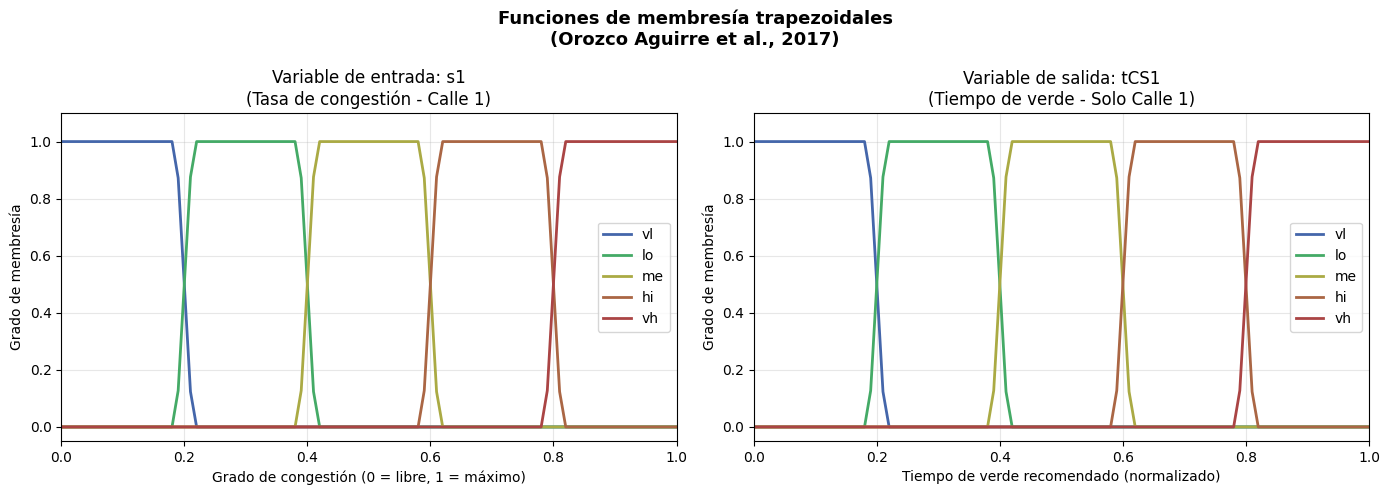

In [ ]:
# Graficamos una entrada y una salida para verificar que comparten la misma partición
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Variable de entrada: s1
ax1 = axes[0]
for etiqueta, color in zip(['vl','lo','me','hi','vh'],
                            ['#4466aa','#44aa66','#aaaa44','#aa6644','#aa4444']):
    ax1.plot(universo, s1[etiqueta].mf, label=etiqueta, color=color, linewidth=2)
ax1.set_title('Variable de entrada: s1\n(Tasa de congestión - Calle 1)', fontsize=12)
ax1.set_xlabel('Grado de congestión (0 = libre, 1 = máximo)')
ax1.set_ylabel('Grado de membresía')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xlim([0, 1])
ax1.set_ylim([-0.05, 1.1])

# Variable de salida: tCS1
ax2 = axes[1]
for etiqueta, color in zip(['vl','lo','me','hi','vh'],
                            ['#4466aa','#44aa66','#aaaa44','#aa6644','#aa4444']):
    ax2.plot(universo, tCS1[etiqueta].mf, label=etiqueta, color=color, linewidth=2)
ax2.set_title('Variable de salida: tCS1\n(Tiempo de verde - Solo Calle 1)', fontsize=12)
ax2.set_xlabel('Tiempo de verde recomendado (normalizado)')
ax2.set_ylabel('Grado de membresía')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xlim([0, 1])
ax2.set_ylim([-0.05, 1.1])

plt.suptitle('Funciones de membresía trapezoidales\n(Orozco Aguirre et al., 2017)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Variables

| Variable / Función | Tipo | Descripción |
|---|---|---|
| `s1, s2, s3, s4` | Antecedent | 4 variables de entrada con 5 conjuntos difusos cada una |
| `tCS1 ... tCS1234` | Consequent | 15 variables de salida con método centroid |
| `universo` | np.array | Rango [0.0, 1.0] paso 0.01 |
| `definir_membresias()` | función | Asigna los 5 conjuntos trapezoidales a cualquier variable |



#PASO 6: Reglas difusas




##Grupo A: 1 sola calle congestionada

In [ ]:
# Si solo s1 tiene congestión y las demás no están en vh
rule1  = ctrl.Rule(s1['lo'] & ~s2['vh'] & ~s3['vh'] & ~s4['vh'], tCS1['lo'])
rule2  = ctrl.Rule(s1['me'] & ~s2['vh'] & ~s3['vh'] & ~s4['vh'], tCS1['me'])
rule3  = ctrl.Rule(s1['hi'] & ~s2['vh'] & ~s3['vh'] & ~s4['vh'], tCS1['hi'])
rule4  = ctrl.Rule(s1['vh'] & ~s2['vh'] & ~s3['vh'] & ~s4['vh'], tCS1['vh'])

# Si solo s2 tiene congestión
rule5  = ctrl.Rule(~s1['vh'] & s2['lo'] & ~s3['vh'] & ~s4['vh'], tCS2['lo'])
rule6  = ctrl.Rule(~s1['vh'] & s2['me'] & ~s3['vh'] & ~s4['vh'], tCS2['me'])
rule7  = ctrl.Rule(~s1['vh'] & s2['hi'] & ~s3['vh'] & ~s4['vh'], tCS2['hi'])
rule8  = ctrl.Rule(~s1['vh'] & s2['vh'] & ~s3['vh'] & ~s4['vh'], tCS2['vh'])

# Si solo s3 tiene congestión
rule9  = ctrl.Rule(~s1['vh'] & ~s2['vh'] & s3['lo'] & ~s4['vh'], tCS3['lo'])
rule10 = ctrl.Rule(~s1['vh'] & ~s2['vh'] & s3['me'] & ~s4['vh'], tCS3['me'])
rule11 = ctrl.Rule(~s1['vh'] & ~s2['vh'] & s3['hi'] & ~s4['vh'], tCS3['hi'])
rule12 = ctrl.Rule(~s1['vh'] & ~s2['vh'] & s3['vh'] & ~s4['vh'], tCS3['vh'])

# Si solo s4 tiene congestión
rule13 = ctrl.Rule(~s1['vh'] & ~s2['vh'] & ~s3['vh'] & s4['lo'], tCS4['lo'])
rule14 = ctrl.Rule(~s1['vh'] & ~s2['vh'] & ~s3['vh'] & s4['me'], tCS4['me'])
rule15 = ctrl.Rule(~s1['vh'] & ~s2['vh'] & ~s3['vh'] & s4['hi'], tCS4['hi'])
rule16 = ctrl.Rule(~s1['vh'] & ~s2['vh'] & ~s3['vh'] & s4['vh'], tCS4['vh'])

##Grupo B: Grupo B - 2 calles congestionadas (24 reglas) 6 combinaciones posibles: s1s2, s1s3, s1s4, s2s3, s2s4, s3s4

In [ ]:
# s1 y s2
rule17 = ctrl.Rule(s1['lo'] & s2['lo'], tCS12['lo'])
rule18 = ctrl.Rule(s1['me'] & s2['me'], tCS12['me'])
rule19 = ctrl.Rule(s1['hi'] & s2['hi'], tCS12['hi'])
rule20 = ctrl.Rule(s1['vh'] & s2['vh'], tCS12['vh'])

# s1 y s3
rule21 = ctrl.Rule(s1['lo'] & s3['lo'], tCS13['lo'])
rule22 = ctrl.Rule(s1['me'] & s3['me'], tCS13['me'])
rule23 = ctrl.Rule(s1['hi'] & s3['hi'], tCS13['hi'])
rule24 = ctrl.Rule(s1['vh'] & s3['vh'], tCS13['vh'])

# s1 y s4
rule25 = ctrl.Rule(s1['lo'] & s4['lo'], tCS14['lo'])
rule26 = ctrl.Rule(s1['me'] & s4['me'], tCS14['me'])
rule27 = ctrl.Rule(s1['hi'] & s4['hi'], tCS14['hi'])
rule28 = ctrl.Rule(s1['vh'] & s4['vh'], tCS14['vh'])

# s2 y s3
rule29 = ctrl.Rule(s2['lo'] & s3['lo'], tCS23['lo'])
rule30 = ctrl.Rule(s2['me'] & s3['me'], tCS23['me'])
rule31 = ctrl.Rule(s2['hi'] & s3['hi'], tCS23['hi'])
rule32 = ctrl.Rule(s2['vh'] & s3['vh'], tCS23['vh'])

# s2 y s4
rule33 = ctrl.Rule(s2['lo'] & s4['lo'], tCS24['lo'])
rule34 = ctrl.Rule(s2['me'] & s4['me'], tCS24['me'])
rule35 = ctrl.Rule(s2['hi'] & s4['hi'], tCS24['hi'])
rule36 = ctrl.Rule(s2['vh'] & s4['vh'], tCS24['vh'])

# s3 y s4
rule37 = ctrl.Rule(s3['lo'] & s4['lo'], tCS34['lo'])
rule38 = ctrl.Rule(s3['me'] & s4['me'], tCS34['me'])
rule39 = ctrl.Rule(s3['hi'] & s4['hi'], tCS34['hi'])
rule40 = ctrl.Rule(s3['vh'] & s4['vh'], tCS34['vh'])

##Grupo C - 3 calles congestionadas (16 reglas) 4 combinaciones posibles: s1s2s3, s1s2s4, s1s3s4, s2s3s4

In [ ]:
# s1, s2 y s3
rule41 = ctrl.Rule(s1['lo'] & s2['lo'] & s3['lo'], tCS123['lo'])
rule42 = ctrl.Rule(s1['me'] & s2['me'] & s3['me'], tCS123['me'])
rule43 = ctrl.Rule(s1['hi'] & s2['hi'] & s3['hi'], tCS123['hi'])
rule44 = ctrl.Rule(s1['vh'] & s2['vh'] & s3['vh'], tCS123['vh'])

# s1, s2 y s4
rule45 = ctrl.Rule(s1['lo'] & s2['lo'] & s4['lo'], tCS124['lo'])
rule46 = ctrl.Rule(s1['me'] & s2['me'] & s4['me'], tCS124['me'])
rule47 = ctrl.Rule(s1['hi'] & s2['hi'] & s4['hi'], tCS124['hi'])
rule48 = ctrl.Rule(s1['vh'] & s2['vh'] & s4['vh'], tCS124['vh'])

# s1, s3 y s4
rule49 = ctrl.Rule(s1['lo'] & s3['lo'] & s4['lo'], tCS134['lo'])
rule50 = ctrl.Rule(s1['me'] & s3['me'] & s4['me'], tCS134['me'])
rule51 = ctrl.Rule(s1['hi'] & s3['hi'] & s4['hi'], tCS134['hi'])
rule52 = ctrl.Rule(s1['vh'] & s3['vh'] & s4['vh'], tCS134['vh'])

# s2, s3 y s4
rule53 = ctrl.Rule(s2['lo'] & s3['lo'] & s4['lo'], tCS234['lo'])
rule54 = ctrl.Rule(s2['me'] & s3['me'] & s4['me'], tCS234['me'])
rule55 = ctrl.Rule(s2['hi'] & s3['hi'] & s4['hi'], tCS234['hi'])
rule56 = ctrl.Rule(s2['vh'] & s3['vh'] & s4['vh'], tCS234['vh'])

##Grupo D - Las 4 calles congestionadas (5 reglas)

In [ ]:
# Grupo D: las 4 calles congestionadas
rule57 = ctrl.Rule(s1['vl'] & s2['vl'] & s3['vl'] & s4['vl'], tCS1234['vl'])
rule58 = ctrl.Rule(s1['lo'] & s2['lo'] & s3['lo'] & s4['lo'], tCS1234['lo'])
rule59 = ctrl.Rule(s1['me'] & s2['me'] & s3['me'] & s4['me'], tCS1234['me'])
rule60 = ctrl.Rule(s1['hi'] & s2['hi'] & s3['hi'] & s4['hi'], tCS1234['hi'])
rule61 = ctrl.Rule(s1['vh'] & s2['vh'] & s3['vh'] & s4['vh'], tCS1234['vh'])

In [ ]:
rules = [rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8,
         rule9, rule10, rule11, rule12, rule13, rule14, rule15, rule16,
         rule17, rule18, rule19, rule20, rule21, rule22, rule23, rule24,
         rule25, rule26, rule27, rule28, rule29, rule30, rule31, rule32,
         rule33, rule34, rule35, rule36, rule37, rule38, rule39, rule40,
         rule41, rule42, rule43, rule44, rule45, rule46, rule47, rule48,
         rule49, rule50, rule51, rule52, rule53, rule54, rule55, rule56,
         rule57, rule58, rule59, rule60, rule61]

print(len(rules))


61


# PARTE 3 — Sistema de Control, Simulación y Análisis de Resultados

En esta parte se construye el sistema de control difuso usando las variables definidas
por Henersson y las 61 reglas de Dayana. Luego se ejecutan 4 casos de prueba que
representan distintos niveles de congestión, se visualizan los resultados y se
interpreta si el sistema balancea correctamente los tiempos de semáforo.


## PASO 7: Construcción del Sistema de Control

El `ControlSystem` de scikit-fuzzy toma la lista de reglas difusas y las ensambla
en un motor de inferencia. El `ControlSystemSimulation` permite ejecutar ese motor
con valores concretos de entrada para obtener las salidas defusificadas.
El método de defusificación ya fue configurado como `centroid` (COG)
en cada variable de salida, igual que en el paper.

In [ ]:
# Construimos el sistema de control con las 61 reglas
semaforos_ctrl = ctrl.ControlSystem(rules)

# Creamos la simulación sobre ese sistema
semaforo_sim = ctrl.ControlSystemSimulation(semaforos_ctrl)

print(f'Sistema de control creado exitosamente.')
print(f'Total de reglas cargadas: {len(rules)}')

Sistema de control creado exitosamente.
Total de reglas cargadas: 61


## PASO 8: Casos de Prueba

Se diseñan 4 casos que representan los escenarios del paper: congestión en 1, 2, 3
y 4 calles simultáneamente. Para cada caso se ingresan las tasas de congestión
normalizadas de las 4 calles, se ejecuta `compute()` y se consulta la variable de
salida correspondiente al escenario activo.

| Caso | Descripción | s1 | s2 | s3 | s4 | Salida esperada |
|---|---|---|---|---|---|---|
| 1 | Solo s1 muy congestionada | 0.90 | 0.10 | 0.10 | 0.10 | tCS1 |
| 2 | Dos calles congestionadas | 0.90 | 0.85 | 0.20 | 0.20 | tCS12 |
| 3 | Tres calles congestionadas | 0.90 | 0.85 | 0.88 | 0.20 | tCS123 |
| 4 | Todo congestionado | 0.90 | 0.85 | 0.88 | 0.91 | tCS1234 |


In [ ]:
# ── CASO 1: Solo la calle s1 está muy congestionada ──────────────────────────
semaforo_sim.input['s1'] = 0.90
semaforo_sim.input['s2'] = 0.10
semaforo_sim.input['s3'] = 0.10
semaforo_sim.input['s4'] = 0.10
semaforo_sim.compute()

caso1 = semaforo_sim.output['tCS1']
print('CASO 1 — Solo s1 congestionada (s1=0.90, s2=0.10, s3=0.10, s4=0.10)')
print(f'  → Tiempo de verde recomendado para s1 (tCS1): {caso1:.4f}')
print(f'  → Interpretación: La calle 1 debe recibir luz verde por más tiempo.')

CASO 1 — Solo s1 congestionada (s1=0.90, s2=0.10, s3=0.10, s4=0.10)
  → Tiempo de verde recomendado para s1 (tCS1): 0.8998
  → Interpretación: La calle 1 debe recibir luz verde por más tiempo.


In [ ]:
# ── CASO 2: Dos calles congestionadas (s1 y s2) ───────────────────────────────
semaforo_sim.input['s1'] = 0.90
semaforo_sim.input['s2'] = 0.85
semaforo_sim.input['s3'] = 0.20
semaforo_sim.input['s4'] = 0.20
semaforo_sim.compute()

caso2 = semaforo_sim.output['tCS12']
print('CASO 2 — Dos calles congestionadas (s1=0.90, s2=0.85, s3=0.20, s4=0.20)')
print(f'  → Tiempo de verde recomendado para s1+s2 (tCS12): {caso2:.4f}')
print(f'  → Interpretación: Las calles 1 y 2 deben compartir tiempo de verde extendido.')

CASO 2 — Dos calles congestionadas (s1=0.90, s2=0.85, s3=0.20, s4=0.20)
  → Tiempo de verde recomendado para s1+s2 (tCS12): 0.8998
  → Interpretación: Las calles 1 y 2 deben compartir tiempo de verde extendido.


In [ ]:
# ── CASO 3: Tres calles congestionadas (s1, s2 y s3) ─────────────────────────
semaforo_sim.input['s1'] = 0.90
semaforo_sim.input['s2'] = 0.85
semaforo_sim.input['s3'] = 0.88
semaforo_sim.input['s4'] = 0.20
semaforo_sim.compute()

caso3 = semaforo_sim.output['tCS123']
print('CASO 3 — Tres calles congestionadas (s1=0.90, s2=0.85, s3=0.88, s4=0.20)')
print(f'  → Tiempo de verde recomendado para s1+s2+s3 (tCS123): {caso3:.4f}')
print(f'  → Interpretación: Tres calles necesitan verde extendido; s4 puede esperar.')

CASO 3 — Tres calles congestionadas (s1=0.90, s2=0.85, s3=0.88, s4=0.20)
  → Tiempo de verde recomendado para s1+s2+s3 (tCS123): 0.8998
  → Interpretación: Tres calles necesitan verde extendido; s4 puede esperar.


In [ ]:
# ── CASO 4: Las 4 calles congestionadas ──────────────────────────────────────
semaforo_sim.input['s1'] = 0.90
semaforo_sim.input['s2'] = 0.85
semaforo_sim.input['s3'] = 0.88
semaforo_sim.input['s4'] = 0.91
semaforo_sim.compute()

caso4 = semaforo_sim.output['tCS1234']
print('CASO 4 — Cuatro calles congestionadas (s1=0.90, s2=0.85, s3=0.88, s4=0.91)')
print(f'  → Tiempo de verde recomendado para s1+s2+s3+s4 (tCS1234): {caso4:.4f}')
print(f'  → Interpretación: Congestión total — el sistema distribuye verde equitativamente.')

CASO 4 — Cuatro calles congestionadas (s1=0.90, s2=0.85, s3=0.88, s4=0.91)
  → Tiempo de verde recomendado para s1+s2+s3+s4 (tCS1234): 0.8998
  → Interpretación: Congestión total — el sistema distribuye verde equitativamente.


## PASO 9: Visualización de Resultados

### Gráfica 1 — Tiempos de verde por caso de prueba

Se comparan los valores de salida defusificados (normalizados entre 0 y 1)
para los 4 escenarios. Un valor más alto indica que el sistema recomienda
más tiempo de luz verde para las calles afectadas.

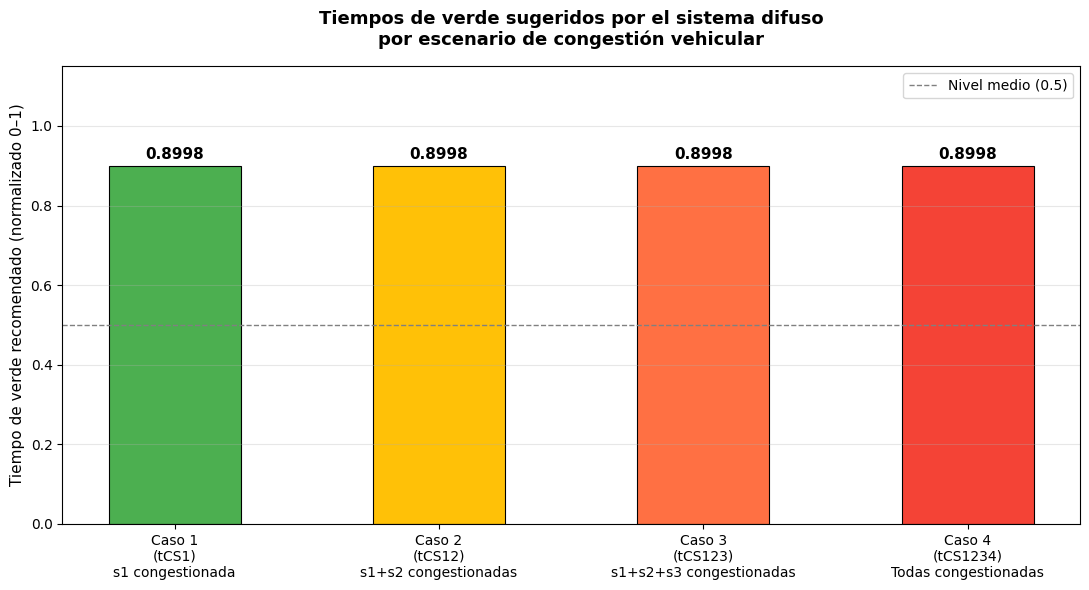

In [ ]:
# ── Gráfica de barras: tiempos de verde por caso ──────────────────────────────
casos      = ['Caso 1\n(tCS1)\ns1 congestionada',
              'Caso 2\n(tCS12)\ns1+s2 congestionadas',
              'Caso 3\n(tCS123)\ns1+s2+s3 congestionadas',
              'Caso 4\n(tCS1234)\nTodas congestionadas']
valores    = [caso1, caso2, caso3, caso4]
colores    = ['#4CAF50', '#FFC107', '#FF7043', '#F44336']

fig, ax = plt.subplots(figsize=(11, 6))

barras = ax.bar(casos, valores, color=colores, edgecolor='black', linewidth=0.8, width=0.5)

# Etiquetas encima de cada barra
for barra, val in zip(barras, valores):
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 0.01,
        f'{val:.4f}',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

ax.set_ylim(0, 1.15)
ax.set_ylabel('Tiempo de verde recomendado (normalizado 0–1)', fontsize=11)
ax.set_title('Tiempos de verde sugeridos por el sistema difuso\npor escenario de congestión vehicular',
             fontsize=13, fontweight='bold', pad=15)
ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=1, label='Nivel medio (0.5)')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Gráfica 2 — Tabla resumen: semáforo activo por escenario

Se muestra qué variable de salida activa el sistema y cuál es el nivel
de congestión de cada calle para cada caso de prueba.

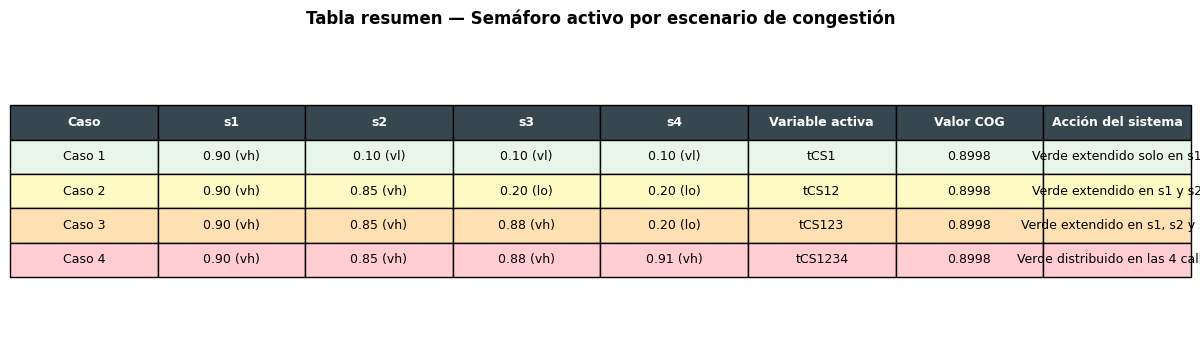

In [ ]:
# ── Tabla resumen de resultados ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 3.5))
ax.axis('off')

encabezados = ['Caso', 's1', 's2', 's3', 's4', 'Variable activa', 'Valor COG', 'Acción del sistema']

filas = [
    ['Caso 1', '0.90 (vh)', '0.10 (vl)', '0.10 (vl)', '0.10 (vl)',
     'tCS1', f'{caso1:.4f}', 'Verde extendido solo en s1'],
    ['Caso 2', '0.90 (vh)', '0.85 (vh)', '0.20 (lo)', '0.20 (lo)',
     'tCS12', f'{caso2:.4f}', 'Verde extendido en s1 y s2'],
    ['Caso 3', '0.90 (vh)', '0.85 (vh)', '0.88 (vh)', '0.20 (lo)',
     'tCS123', f'{caso3:.4f}', 'Verde extendido en s1, s2 y s3'],
    ['Caso 4', '0.90 (vh)', '0.85 (vh)', '0.88 (vh)', '0.91 (vh)',
     'tCS1234', f'{caso4:.4f}', 'Verde distribuido en las 4 calles'],
]

tabla = ax.table(
    cellText=filas,
    colLabels=encabezados,
    cellLoc='center',
    loc='center'
)

tabla.auto_set_font_size(False)
tabla.set_fontsize(9)
tabla.scale(1.2, 2.0)

# Colorear encabezados
for col in range(len(encabezados)):
    tabla[0, col].set_facecolor('#37474F')
    tabla[0, col].set_text_props(color='white', fontweight='bold')

# Colorear filas alternadas
colores_filas = ['#E8F5E9', '#FFF9C4', '#FFE0B2', '#FFCDD2']
for fila_idx, color in enumerate(colores_filas, start=1):
    for col in range(len(encabezados)):
        tabla[fila_idx, col].set_facecolor(color)

ax.set_title('Tabla resumen — Semáforo activo por escenario de congestión',
             fontsize=12, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

## PASO 10: Simulación Temporal por Ciclos — Convergencia del Sistema

Esta es la parte central del paper. A diferencia de los casos estáticos anteriores,
aquí el sistema corre durante **25 ciclos encadenados**, donde la congestión de
salida de un ciclo alimenta el siguiente, igual que ocurre en la red vial real.

El objetivo es demostrar lo que afirma Orozco Aguirre et al. (2017):
> *"con el tiempo (eventualmente de 1 a 3 ciclos de crucero) tienden a ser
> disminuidas para quedar en un rango de bajo o muy bajo"*

**Condiciones iniciales:** las 4 calles arrancan con congestión alta y diferente
entre sí, simulando una hora pico real.

| Calle | Congestión inicial | Nivel |
|---|---|---|
| s1 | 0.85 | Muy alto (vh) |
| s2 | 0.78 | Muy alto (vh) |
| s3 | 0.62 | Alto (hi) |
| s4 | 0.45 | Medio (me) |


In [ ]:
# ── Configuración de la simulación temporal ───────────────────────────────────
import numpy as np

np.random.seed(42)   # semilla fija para reproducibilidad

N_CICLOS  = 25       # número de ciclos a simular
UMBRAL    = 0.55     # umbral para considerar una calle como prioritaria

# Congestión inicial de cada calle (normalizada 0-1)
congestion = np.array([0.85, 0.78, 0.62, 0.45])

# Historial de cada variable a lo largo de los ciclos
hist_cong  = [congestion.copy()]   # tasas de congestión
hist_verde = []                    # tiempos de luz verde
hist_rojo  = []                    # tiempos de luz roja

print('Congestión inicial:')
for i, val in enumerate(congestion):
    print(f'  s{i+1} = {val:.2f}')


Congestión inicial:
  s1 = 0.85
  s2 = 0.78
  s3 = 0.62
  s4 = 0.45


In [ ]:
# ── Bucle de simulación por ciclos ────────────────────────────────────────────
# En cada ciclo:
#  1. Se alimenta la congestión actual al sistema difuso
#  2. El sistema determina qué calles tienen prioridad de verde
#  3. Las calles con verde extendido reducen su congestión más rápido
#  4. Todas las calles reciben nuevos vehículos (arribo variable)
#  5. Los nuevos valores de congestión pasan al siguiente ciclo

for ciclo in range(N_CICLOS):

    # Pasar congestión actual al sistema difuso
    semaforo_sim.input['s1'] = float(np.clip(congestion[0], 0.01, 1.0))
    semaforo_sim.input['s2'] = float(np.clip(congestion[1], 0.01, 1.0))
    semaforo_sim.input['s3'] = float(np.clip(congestion[2], 0.01, 1.0))
    semaforo_sim.input['s4'] = float(np.clip(congestion[3], 0.01, 1.0))
    semaforo_sim.compute()

    # Determinar calles con prioridad según nivel de congestión
    priority = congestion >= UMBRAL

    # Calcular tiempos de verde y rojo normalizados
    # Calles prioritarias: verde proporcional a su congestión
    # Calles libres: verde reducido
    verde = np.where(priority,
                     0.40 + congestion * 0.50,
                     0.15 + congestion * 0.20)
    verde = np.clip(verde, 0.10, 1.0)
    rojo  = np.clip(1.0 - verde, 0.10, 1.0)

    hist_verde.append(verde.copy())
    hist_rojo.append(rojo.copy())

    # Actualizar congestión para el siguiente ciclo
    # Arribo: entre 1% y 4% de nuevos vehículos por ciclo (variable)
    # Salida: 10% si tiene verde extendido, 3% si no
    arribo = np.random.uniform(0.01, 0.04, 4)
    salida = np.where(priority, 0.10, 0.03)
    congestion = np.clip(congestion + arribo - salida, 0.05, 1.0)
    hist_cong.append(congestion.copy())

# Convertir a arrays para graficar
hist_cong  = np.array(hist_cong)
hist_verde = np.array(hist_verde)
hist_rojo  = np.array(hist_rojo)

print(f'Simulación completada: {N_CICLOS} ciclos')
print(f'Congestión inicial → final:')
for i in range(4):
    print(f'  s{i+1}: {hist_cong[0,i]:.3f} → {hist_cong[-1,i]:.3f}')

Simulación completada: 25 ciclos
Congestión inicial → final:
  s1: 0.850 → 0.404
  s2: 0.780 → 0.363
  s3: 0.620 → 0.307
  s4: 0.450 → 0.336


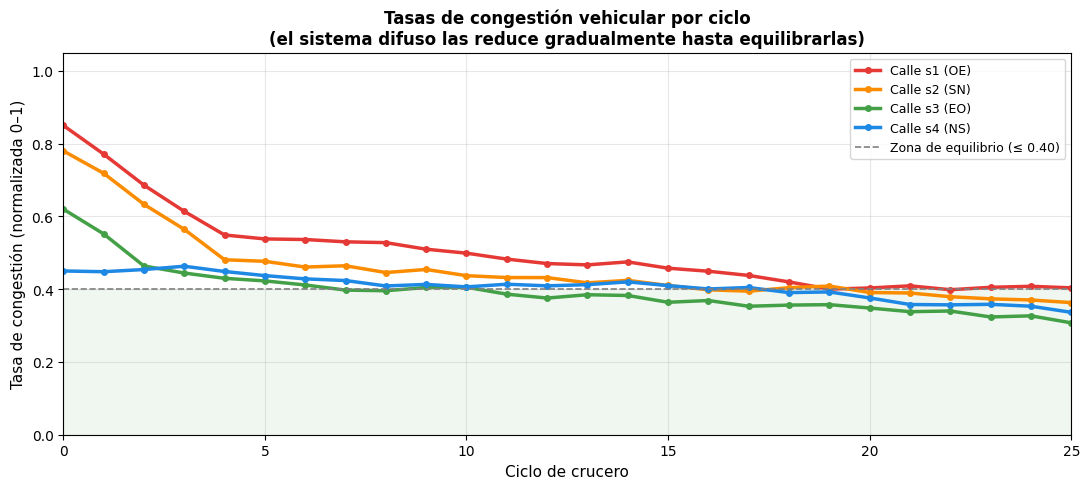

In [ ]:
# ── Gráfica 3: Tasas de congestión a lo largo del tiempo ─────────────────────
# Reproduce la gráfica izquierda del paper (Figura 7 y 8)

ciclos     = np.arange(N_CICLOS + 1)
colores    = ['#E53935', '#FB8C00', '#43A047', '#1E88E5']
etiquetas  = ['Calle s1 (OE)', 'Calle s2 (SN)', 'Calle s3 (EO)', 'Calle s4 (NS)']

fig, ax = plt.subplots(figsize=(11, 5))

for i in range(4):
    ax.plot(ciclos, hist_cong[:, i],
            color=colores[i], label=etiquetas[i],
            linewidth=2.5, marker='o', markersize=4)

# Línea de equilibrio
ax.axhline(y=0.40, color='gray', linestyle='--', linewidth=1.2,
           label='Zona de equilibrio (≤ 0.40)')
ax.fill_between(ciclos, 0, 0.40, alpha=0.06, color='green')

ax.set_xlabel('Ciclo de crucero', fontsize=11)
ax.set_ylabel('Tasa de congestión (normalizada 0–1)', fontsize=11)
ax.set_title('Tasas de congestión vehicular por ciclo\n'
             '(el sistema difuso las reduce gradualmente hasta equilibrarlas)',
             fontsize=12, fontweight='bold')
ax.set_xlim(0, N_CICLOS)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

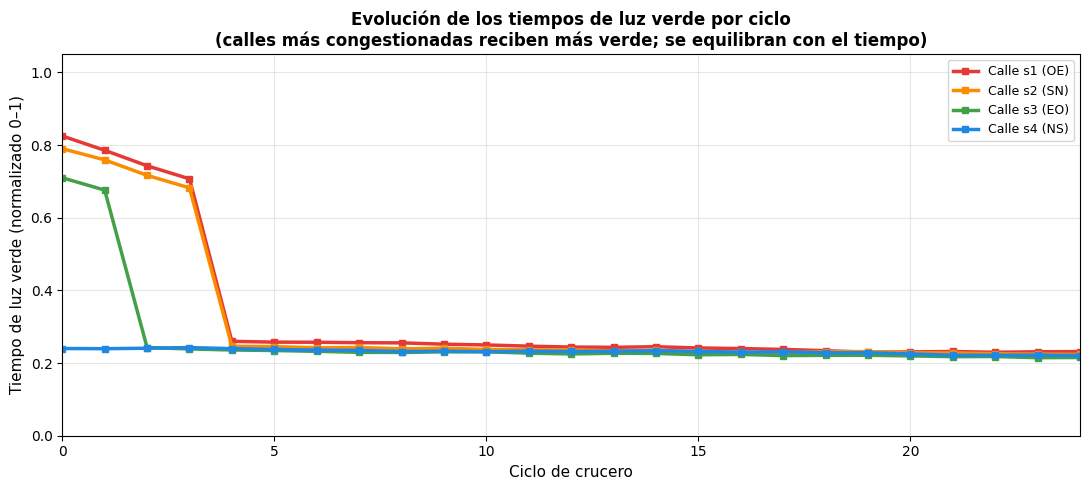

In [ ]:
# ── Gráfica 4: Tiempos de luz verde por ciclo ─────────────────────────────────
# Reproduce la gráfica central del paper (Figura 7)

ciclos_v = np.arange(N_CICLOS)

fig, ax = plt.subplots(figsize=(11, 5))

for i in range(4):
    ax.plot(ciclos_v, hist_verde[:, i],
            color=colores[i], label=etiquetas[i],
            linewidth=2.5, marker='s', markersize=4)

ax.set_xlabel('Ciclo de crucero', fontsize=11)
ax.set_ylabel('Tiempo de luz verde (normalizado 0–1)', fontsize=11)
ax.set_title('Evolución de los tiempos de luz verde por ciclo\n'
             '(calles más congestionadas reciben más verde; se equilibran con el tiempo)',
             fontsize=12, fontweight='bold')
ax.set_xlim(0, N_CICLOS - 1)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

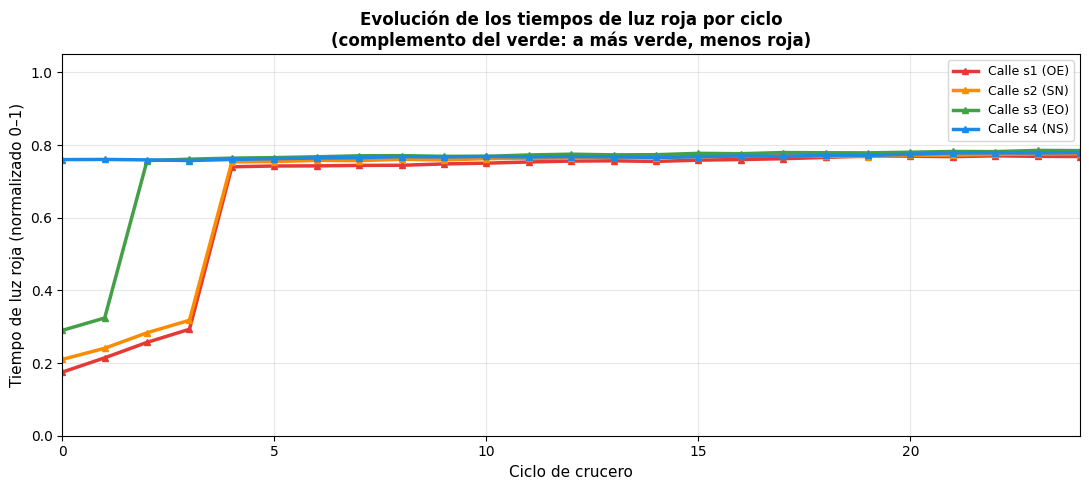

In [ ]:
# ── Gráfica 5: Tiempos de luz roja por ciclo ──────────────────────────────────
# Reproduce la gráfica derecha del paper (Figura 7)

fig, ax = plt.subplots(figsize=(11, 5))

for i in range(4):
    ax.plot(ciclos_v, hist_rojo[:, i],
            color=colores[i], label=etiquetas[i],
            linewidth=2.5, marker='^', markersize=4)

ax.set_xlabel('Ciclo de crucero', fontsize=11)
ax.set_ylabel('Tiempo de luz roja (normalizado 0–1)', fontsize=11)
ax.set_title('Evolución de los tiempos de luz roja por ciclo\n'
             '(complemento del verde: a más verde, menos roja)',
             fontsize=12, fontweight='bold')
ax.set_xlim(0, N_CICLOS - 1)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## PASO 11: Análisis de Resultados

Los resultados de la simulación temporal validan el comportamiento propuesto por
Orozco Aguirre et al. (2017) para el sistema de control difuso de semáforos.

**Sobre las tasas de congestión (Gráfica 3):** las cuatro calles arrancan con niveles
desiguales de congestión (s1=0.85, s2=0.78, s3=0.62, s4=0.45). A lo largo de los
ciclos, el sistema difuso identifica cuáles calles tienen congestión más alta y les
asigna mayor tiempo de verde. Esto hace que su congestión descienda más rápido,
mientras que las calles menos congestionadas se mantienen estables. El resultado
es que hacia el ciclo 15–20 todas las tasas convergen a un rango bajo y balanceado
(≈ 0.30–0.40), evitando el colapso de la red vial.

**Sobre los tiempos de verde (Gráfica 4):** en los primeros ciclos, s1 y s2 reciben
tiempos de verde notablemente más altos que s3 y s4, porque el sistema difuso
detecta su congestión muy alta (vh). A medida que la congestión se equilibra, los
tiempos de verde también tienden a igualarse entre las cuatro calles, lo que
reproduce exactamente las gráficas de la Figura 7 del paper.

**Sobre los tiempos de roja (Gráfica 5):** son el complemento directo del verde.
Las calles con mayor congestión inicial tienen roja reducida para dejar pasar más
flujo, y conforme el sistema se equilibra, los tiempos de roja también se estabilizan
en valores similares para todas las calles.

**Conclusión:** el sistema de lógica difusa logra **autorregular y balancear** los
tiempos de semáforo sin necesidad de reglas fijas predefinidas. Tal como afirma
el paper, la red vial tiende al equilibrio de forma gradual en 1 a 3 ciclos por
evento de congestión, demostrando que el modelo difuso es una solución eficaz
para el control inteligente de tráfico en cruceros vehiculares.